# Step 1: Data Collection from ChEMBL

Query ChEMBL for all compounds tested against EGFR (CHEMBL203), download pChEMBL values,
and filter for high-quality, single-protein assays.

In [1]:
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client
import os

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 1.1 Query ChEMBL for EGFR Target

In [2]:
# Search for EGFR target
target = new_client.target
target_query = target.search('EGFR')
targets_df = pd.DataFrame.from_dict(target_query)
targets_df[['target_chembl_id', 'organism', 'pref_name', 'target_type']].head(10)

,target_chembl_id,organism,pref_name,target_type
0,CHEMBL3608,Mus musculus,Epidermal growth factor receptor,SINGLE PROTEIN
1,CHEMBL4523747,Homo sapiens,EGFR/PPP1CA,PROTEIN-PROTEIN INTERACTION
2,CHEMBL5465557,Homo sapiens,CCN2-EGFR,PROTEIN-PROTEIN INTERACTION
3,CHEMBL203,Homo sapiens,Epidermal growth factor receptor,SINGLE PROTEIN
4,CHEMBL4523680,Homo sapiens,Protein cereblon/Epidermal growth factor receptor,PROTEIN-PROTEIN INTERACTION
5,CHEMBL2111431,Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,PROTEIN FAMILY
6,CHEMBL2363049,Homo sapiens,Epidermal growth factor receptor,PROTEIN FAMILY
7,CHEMBL4523998,Homo sapiens,von Hippel-Lindau disease tumor suppressor/EGFR,PROTEIN-PROTEIN INTERACTION
8,CHEMBL4630723,Homo sapiens,ErbB-2/ErbB-3 heterodimer,PROTEIN COMPLEX
9,CHEMBL1824,Homo sapiens,Receptor tyrosine-protein kinase erbB-2,SINGLE PROTEIN


In [3]:
# Select human EGFR (CHEMBL203)
selected_target = 'CHEMBL203'
print(f"Selected target: {selected_target} (Human EGFR)")

Selected target: CHEMBL203 (Human EGFR)


## 1.2 Fetch Bioactivity Data

In [4]:
# Query bioactivity data for EGFR
activity = new_client.activity
results = activity.filter(
    target_chembl_id=selected_target,
    pchembl_value__isnull=False,
    assay_type='B'  # Binding assays only
)

# Convert to DataFrame
bioactivity_df = pd.DataFrame.from_dict(results)
print(f"Total records fetched: {len(bioactivity_df)}")
bioactivity_df.head()

Total records fetched: 19067


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.041
1,None,None,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,0.17
2,None,None,32680,[],CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,9.3
3,None,None,32780,[],CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,None,None,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,IC50,uM,UO_0000065,None,96.0
4,None,None,32781,[],CHEMBL675636,Inhibitory concentration of EGF dependent auto...,B,None,None,BAO_0000192,...,Homo sapiens,Epidermal growth factor receptor,9606,None,None,Ki,uM,UO_0000065,None,24.0


In [5]:
# Check available columns
print("Columns:", bioactivity_df.columns.tolist())
print(f"\nStandard types:\n{bioactivity_df['standard_type'].value_counts()}")

Columns: ['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']

Standard types:
standard_type
IC50    17395
Kd        883
Ki        467
EC50      320
ED50        2
Name: count, dtype: int64


## 1.3 Filter for Quality Data

In [6]:
# Keep only IC50, Ki, Kd measurements
valid_types = ['IC50', 'Ki', 'Kd']
df = bioactivity_df[bioactivity_df['standard_type'].isin(valid_types)].copy()
print(f"After filtering standard types: {len(df)} records")

# Ensure pChEMBL values are numeric
df['pchembl_value'] = pd.to_numeric(df['pchembl_value'], errors='coerce')
df = df.dropna(subset=['pchembl_value', 'canonical_smiles'])
print(f"After dropping missing values: {len(df)} records")

# Remove duplicates: keep one measurement per compound (mean pChEMBL)
df_dedup = df.groupby('canonical_smiles').agg(
    pchembl_value=('pchembl_value', 'mean'),
    molecule_chembl_id=('molecule_chembl_id', 'first'),
    standard_type=('standard_type', 'first')
).reset_index()

print(f"Unique compounds: {len(df_dedup)}")

After filtering standard types: 18745 records
After dropping missing values: 18728 records
Unique compounds: 10413


In [7]:
# Basic statistics of pChEMBL values
print(df_dedup['pchembl_value'].describe())

# Filter out extreme outliers (keep pChEMBL between 3 and 12)
df_clean = df_dedup[
    (df_dedup['pchembl_value'] >= 3) & 
    (df_dedup['pchembl_value'] <= 12)
].copy()
print(f"\nAfter outlier removal: {len(df_clean)} compounds")

count    10413.000000
mean         6.954293
std          1.294811
min          4.000000
25%          6.000000
50%          7.023333
75%          7.960000
max         11.000000
Name: pchembl_value, dtype: float64

After outlier removal: 10413 compounds


## 1.4 Visualize Data Distribution

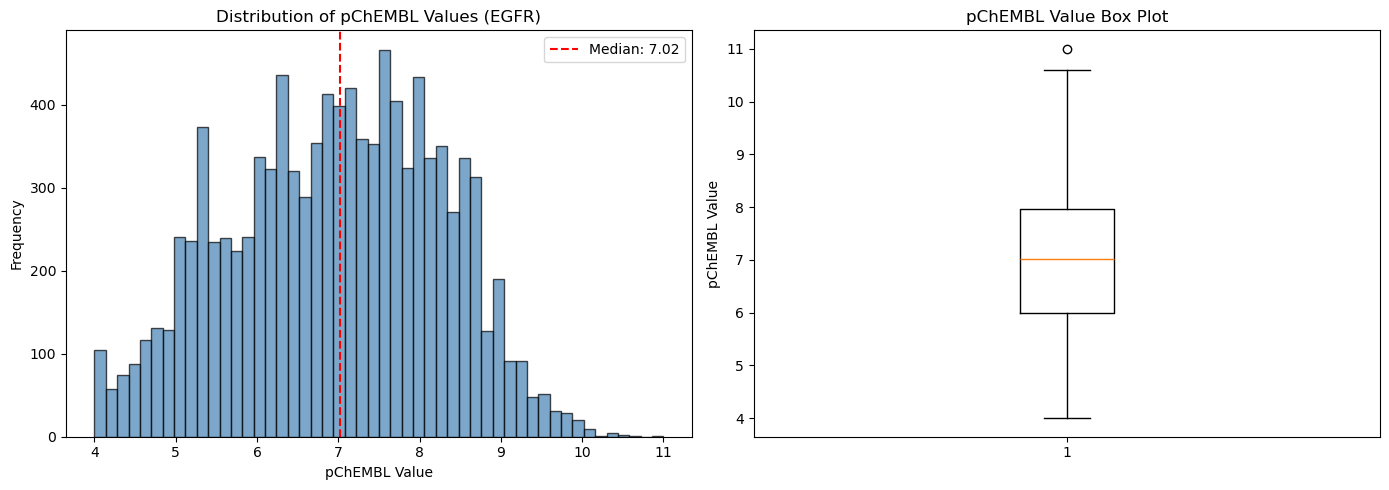

Dataset size: 10413 compounds


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of pChEMBL values
axes[0].hist(df_clean['pchembl_value'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('pChEMBL Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of pChEMBL Values (EGFR)')
axes[0].axvline(df_clean['pchembl_value'].median(), color='red', linestyle='--', label=f"Median: {df_clean['pchembl_value'].median():.2f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df_clean['pchembl_value'], vert=True)
axes[1].set_ylabel('pChEMBL Value')
axes[1].set_title('pChEMBL Value Box Plot')

plt.tight_layout()
plt.savefig('../data/raw/pchembl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Dataset size: {len(df_clean)} compounds")

## 1.5 Save Cleaned Dataset

In [9]:
# Save the cleaned dataset
df_clean.to_csv('../data/raw/egfr_bioactivity.csv', index=False)
print(f"Saved {len(df_clean)} compounds to data/raw/egfr_bioactivity.csv")
print(f"\nDataset summary:")
print(f"  Compounds: {len(df_clean)}")
print(f"  pChEMBL range: {df_clean['pchembl_value'].min():.2f} - {df_clean['pchembl_value'].max():.2f}")
print(f"  pChEMBL mean: {df_clean['pchembl_value'].mean():.2f}")

Saved 10413 compounds to data/raw/egfr_bioactivity.csv

Dataset summary:
  Compounds: 10413
  pChEMBL range: 4.00 - 11.00
  pChEMBL mean: 6.95
